# Question
 Recall the pattern generation and the Delayed Column Generation (DCG) algorithm for the 1D Cutting
Stock Problem (CSP). Instead of one, there are two types of stock. The following details are provided in the file **3items.xlsx** :

• The length of the different stocks is provided in stocks sheet.

• The length and corresponding demand of the different items (to be cut from the stocks) are provided
in items sheet.


(a) Generate all ‘good’ patterns - that yield a trim-loss of less than or equal to 2, and use just these
patterns to solve the CSP (LP relaxation). If you get a fractional solution, round it up.
The code must print:
1. total number of patterns generated
2. total number of stocks of each type used in the optimal solution
3. computational time taken in seconds for pattern generation and solving the model

In [1]:
import time

start_time = time.perf_counter()

import numpy as np 
import pandas as pd 
from math import floor
import matplotlib.pyplot as plt

In [2]:
def duplicate_remover(list_):
    # Convert each sublist to a tuple and store in a set to remove duplicates
    unique_tuples = set(map(tuple, list_))

    # Convert the unique tuples back to a list of lists
    unique_list = list(map(list, unique_tuples))

    return unique_list

In [3]:
# Opening an excel file and reading each sheet
with pd.ExcelFile("items.xlsx") as xls:
    items_df = pd.read_excel(xls,"items")
    stocks_df = pd.read_excel(xls,"stocks", dtype=float)

items_df

,Item Length,Demand
0,1.5,20
1,2.0,15
2,3.5,13
3,4.5,8
4,5.5,9
5,6.5,5
6,7.0,6
7,8.5,7
8,9.0,4
9,10.5,6


In [4]:
item_lengths = np.array(items_df["Item Length"])
stock_lengths = np.array(stocks_df, dtype='g').flatten()

min_item_length = np.min(item_lengths)

# pattern list of good patterns of each stock type
patterns = []

# loop on different stocks
for i in range(len(stock_lengths)):
    stock_length = stock_lengths[i]
    # good pattern list
    good_pattern = []
    for _ in range(1000000):
        # loop to make patterns
        pattern = []
        k = floor(stock_length/min_item_length)
        for j in range(k):
            # if sum of item lengths + new item length is less than or equal to stock length 
            item_length = np.random.choice(item_lengths)
            if sum(pattern) + item_length<= stock_lengths[i]:
                pattern.append(item_length)
        # Filtering good pattern
        if stock_lengths[i] - sum(pattern) < 2:
            good_pattern.append(sorted(pattern))
    # good pattern as a set along with sorted pattern to remove duplicate entries
    
    # append the good pattern as a list in patterns for each stock type
    patterns.append(duplicate_remover(good_pattern))

In [5]:

pd.options.display.max_rows = 9999

In [6]:
# making a dataframe so as to visualize patterns with column names
patterns_df = pd.DataFrame(patterns).T
patterns_df.columns=[f"Good patterns for the stock length: {i}" for i in stock_lengths]
patterns_df

,Good patterns for the stock length: 10.0,Good patterns for the stock length: 12.0,Good patterns for the stock length: 15.0
0,"[1.5, 1.5, 2.0, 4.5]","[1.5, 1.5, 2.0, 7.0]","[1.5, 1.5, 2.0, 3.5, 5.5]"
1,"[1.5, 2.0, 6.5]","[1.5, 1.5, 1.5, 1.5, 1.5, 4.5]","[1.5, 1.5, 2.0, 4.5, 4.5]"
2,"[1.5, 1.5, 1.5, 5.5]","[1.5, 1.5, 3.5, 5.5]","[1.5, 1.5, 1.5, 1.5, 1.5, 7.0]"
3,"[1.5, 1.5, 1.5, 2.0, 2.0]","[1.5, 4.5, 5.5]","[1.5, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]"
4,"[3.5, 6.5]","[1.5, 1.5, 1.5, 2.0, 5.5]","[1.5, 3.5, 3.5, 6.5]"
5,[8.5],"[1.5, 2.0, 3.5, 3.5]","[1.5, 2.0, 3.5, 6.5]"
6,"[4.5, 5.5]","[1.5, 3.5, 3.5, 3.5]","[1.5, 1.5, 1.5, 2.0, 8.5]"
7,"[2.0, 2.0, 5.5]","[5.5, 6.5]","[1.5, 1.5, 1.5, 2.0, 3.5, 3.5]"
8,"[1.5, 1.5, 6.5]","[1.5, 2.0, 2.0, 5.5]","[1.5, 1.5, 1.5, 1.5, 8.5]"
9,"[1.5, 3.5, 3.5]","[1.5, 1.5, 2.0, 2.0, 4.5]","[1.5, 1.5, 1.5, 3.5, 5.5]"


In [7]:

print(patterns_df.count())
total_patterns = sum([len(i) for i in patterns])
print(f'Total number of good patterns are {total_patterns}')

Good patterns for the stock length: 10.0     37
Good patterns for the stock length: 12.0     67
Good patterns for the stock length: 15.0    143
dtype: int64
Total number of good patterns are 247


In [8]:
patterns_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 3 columns):
 #   Column                                    Non-Null Count  Dtype 
---  ------                                    --------------  ----- 
 0   Good patterns for the stock length: 10.0  37 non-null     object
 1   Good patterns for the stock length: 12.0  67 non-null     object
 2   Good patterns for the stock length: 15.0  143 non-null    object
dtypes: object(3)
memory usage: 3.5+ KB


In [9]:
listA = [[patterns[i][j] for i in range(len(patterns)) for j in range(len(patterns[i]))]]
df = pd.DataFrame(listA).T
df.columns=["Pattern"]

stock_corresponding_to_pattern = []
for j in range(len(patterns)):
    for i in range(len(patterns[j])):
        stock_corresponding_to_pattern.append(stock_lengths[j])

df["Length of stock used"] = stock_corresponding_to_pattern
df

,Pattern,Length of stock used
0,"[1.5, 1.5, 2.0, 4.5]",10.0
1,"[1.5, 2.0, 6.5]",10.0
2,"[1.5, 1.5, 1.5, 5.5]",10.0
3,"[1.5, 1.5, 1.5, 2.0, 2.0]",10.0
4,"[3.5, 6.5]",10.0
5,[8.5],10.0
6,"[4.5, 5.5]",10.0
7,"[2.0, 2.0, 5.5]",10.0
8,"[1.5, 1.5, 6.5]",10.0
9,"[1.5, 3.5, 3.5]",10.0


In [10]:
count_list = []
for i in df["Pattern"]:
    freq = []
    for j in item_lengths:
        num = i.count(j)
        freq.append(num)
    count_list.append(freq)

A = np.matrix(count_list)
pd.DataFrame(A, columns=item_lengths).join(df["Pattern"])

,1.5,2.0,3.5,4.5,5.5,6.5,7.0,8.5,9.0,10.5,13.5,Pattern
0,2,1,0,1,0,0,0,0,0,0,0,"[1.5, 1.5, 2.0, 4.5]"
1,1,1,0,0,0,1,0,0,0,0,0,"[1.5, 2.0, 6.5]"
2,3,0,0,0,1,0,0,0,0,0,0,"[1.5, 1.5, 1.5, 5.5]"
3,3,2,0,0,0,0,0,0,0,0,0,"[1.5, 1.5, 1.5, 2.0, 2.0]"
4,0,0,1,0,0,1,0,0,0,0,0,"[3.5, 6.5]"
5,0,0,0,0,0,0,0,1,0,0,0,[8.5]
6,0,0,0,1,1,0,0,0,0,0,0,"[4.5, 5.5]"
7,0,2,0,0,1,0,0,0,0,0,0,"[2.0, 2.0, 5.5]"
8,2,0,0,0,0,1,0,0,0,0,0,"[1.5, 1.5, 6.5]"
9,1,0,2,0,0,0,0,0,0,0,0,"[1.5, 3.5, 3.5]"


In [11]:
D = items_df["Demand"]
D

0     20
1     15
2     13
3      8
4      9
5      5
6      6
7      7
8      4
9      6
10     5
Name: Demand, dtype: int64

- $s_i$ is the stock length, $\forall i \in N=\{1,2,...,n\}$, $\in \mathbb{Z}^+$
  
- $p_{ij}$ is the good pattern for stock length $i$, $j \in M_i=\{1,2,...,m_i\}, \forall  i \in N$

- $l_k$ is the length of item $k$, $\forall k \in E=\{1,2,...,e\}$,  $\in \mathbb{Z}^+$

- $d_k$ is the demand of item $k$, $\forall k \in E$,  $\in \mathbb{Z}^+$

- $x_{p_{ij}}$ is number of times pattern $p_{ij}$ is used, $\in \mathbb{Z}^+$

- $a_{{l_k}{p_{ij}}}$ is the number of items of length $l_k$ used in pattern $p_{ij}$, $\in \mathbb{Z}^+$

**Decision variable is $x_{p_{ij}}$**

Then, the formulation is the following:
$$\begin{align}
\min \quad & \sum_{p_{ij}\in P} x_{p_{ij}} \\
\text{s.t.} \quad & \sum_{p_{ij}\in P} a_{{l_k}{p_{ij}}} x_{p_{ij}} \geq d_k  && \forall k \in E \\
\end{align}$$

In [12]:
import gurobipy as gp 
from gurobipy import GRB 

In [13]:
# Make a model
m = gp.Model('CuttingStock')

Restricted license - for non-production use only - expires 2027-11-29


In [14]:
# A vetctor containing decision variables with (shape total_patterns,1)
x = m.addMVar(lb=0,vtype=GRB.INTEGER, shape=total_patterns, name="x")

In [15]:
# Objective
m.setObjective(np.ones(total_patterns).T@x, GRB.MINIMIZE)

In [16]:
# Add constraint
c = m.addConstr(A.T@x >= D.to_numpy(), name="c")

In [17]:
# Solve the model
m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Debian GNU/Linux 12 (bookworm)")


CPU model: Intel(R) Xeon(R) Gold 6338 CPU @ 2.00GHz, instruction set [SSE2|AVX|AVX2|AVX512]


Thread count: 64 physical cores, 64 logical processors, using up to 32 threads


Optimize a model with 11 rows, 247 columns and 625 nonzeros (Min)


Model fingerprint: 0xff8f7d9d


...

Explored 1 nodes (23 simplex iterations) in 0.01 seconds (0.00 work units)


Thread count was 32 (of 64 available processors)


Solution count 5: 33 34 35 ... 44


Optimal solution found (tolerance 1.00e-04)


Best objective 3.300000000000e+01, best bound 3.300000000000e+01, gap 0.0000%


In [18]:
if m.status == GRB.OPTIMAL:
    print(f"Optimal objective function value: {m.ObjVal:g}")
    print(f"Decision variables x: {x.X.astype(int)}")
    print(f'Total solve time: {m.Runtime:.4f} seconds')
else:
    print("No Optimal Solution found.")

Optimal objective function value: 33
Decision variables x: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 6 0 0 0 0 0 0 5 0 0 0 0 0 0 2 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 6 0 0 4 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Total solve time: 0.0114 seconds


In [19]:
df["Number of times used"] = x.X.astype(int)

In [20]:
result_df = df[df["Number of times used"]>0]
result_df

,Pattern,Length of stock used,Number of times used
119,"[2.0, 2.0, 2.0, 2.0, 3.5, 3.5]",15.0,2
123,"[4.5, 10.5]",15.0,6
130,"[1.5, 13.5]",15.0,5
137,"[2.0, 2.0, 5.5, 5.5]",15.0,2
140,"[2.0, 2.0, 2.0, 3.5, 5.5]",15.0,1
165,"[1.5, 6.5, 7.0]",15.0,4
192,"[3.5, 4.5, 7.0]",15.0,2
214,"[6.5, 8.5]",15.0,1
217,"[1.5, 1.5, 3.5, 8.5]",15.0,6
220,"[5.5, 9.0]",15.0,4


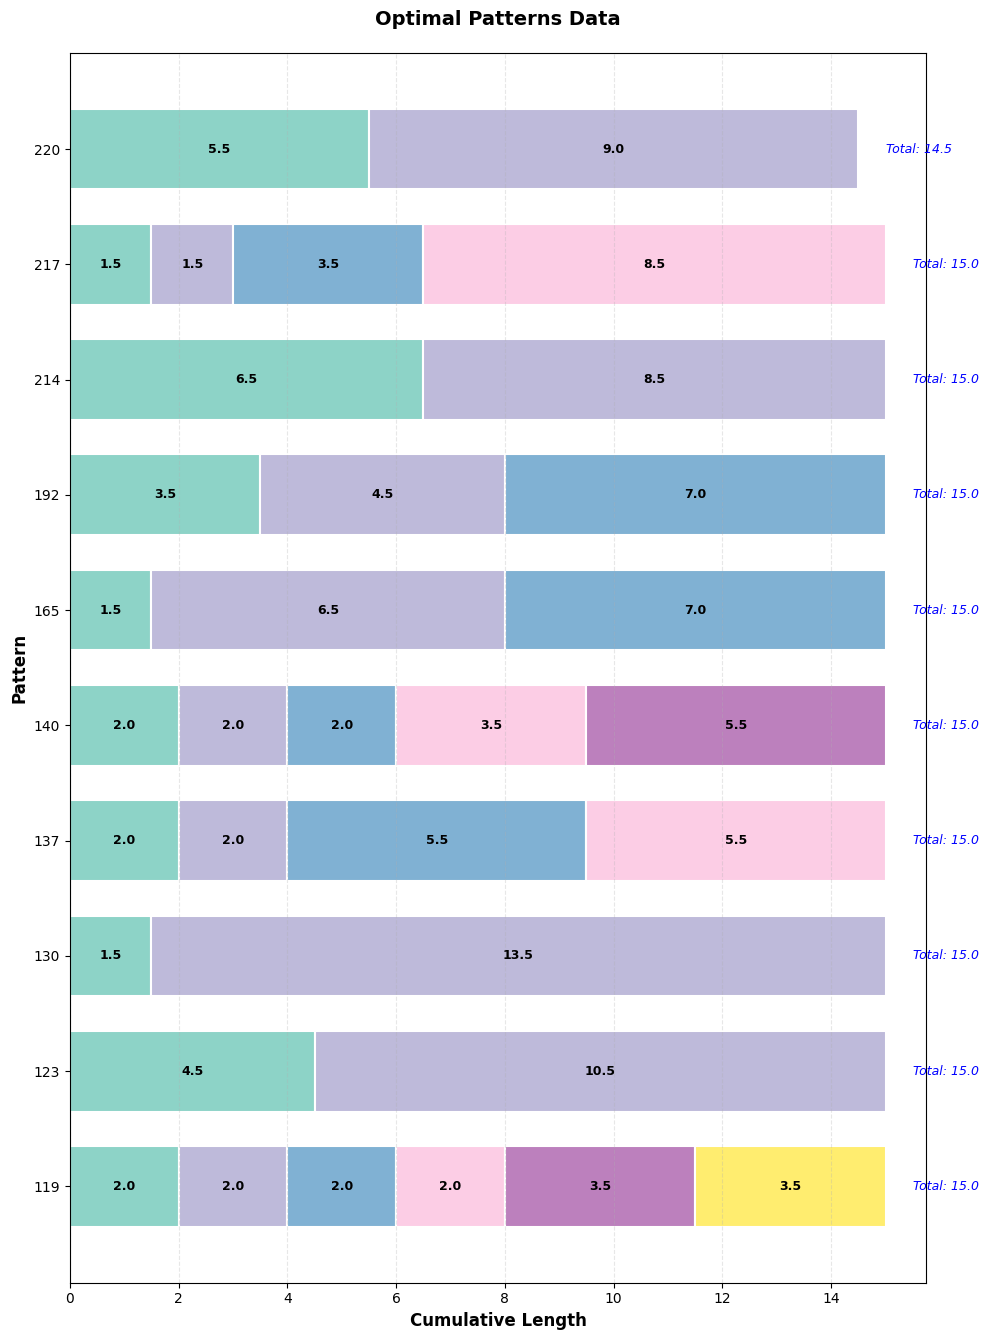

In [21]:
# Create figure
fig, ax = plt.subplots(figsize=(result_df["Pattern"].count(), max(item_lengths)))

# Define colors for segments (using a colormap)
colors = plt.cm.Set3(np.linspace(0, 2, 11))

# Plot each pattern as a horizontal stacked bar
y_positions = range(len(result_df))
labels = result_df.index.tolist()

for i, (index, row) in enumerate(result_df.iterrows()):
    values = row['Pattern']  # Get the list of values from the Pattern column
    left = 0
    for j, value in enumerate(values):
        ax.barh(i, value, left=left, height=0.7, 
                color=colors[j % len(colors)], 
                edgecolor='white', linewidth=1.5)
        # Add value labels on each segment
        ax.text(left + value/2, i, f'{value}', 
                ha='center', va='center', fontsize=9, fontweight='bold')
        left += value

# Customize the plot
ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_xlabel('Cumulative Length', fontsize=12, fontweight='bold')
ax.set_ylabel('Pattern', fontsize=12, fontweight='bold')
ax.set_title('Optimal Patterns Data', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add total value at the end of each bar
for i, (index, row) in enumerate(result_df.iterrows()):
    total = sum(row['Pattern'])
    ax.text(total + 0.5, i, f'Total: {total}', 
            va='center', fontsize=9, style='italic', color='blue')

plt.tight_layout()
plt.savefig('pattern_chart.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
for i in stock_lengths:
    num_stock_used =  result_df.loc[result_df["Length of stock used"] == i,"Number of times used"].sum()
    print(f"Number of stock of length {i} used: {num_stock_used}")

Number of stock of length 10.0 used: 0
Number of stock of length 12.0 used: 0
Number of stock of length 15.0 used: 33


In [23]:
end_time = time.perf_counter()
runtime = end_time - start_time

print(f"The script took {runtime:.4f} seconds to complete.")

The script took 181.3922 seconds to complete.


(b) Implement the DCG algorithm to solve the CSP (LP relaxation), starting with ‘identity patterns’.
You can implement any variant of your choice, given there are multiple stocks. If you get a fractional
solution, round it up.
Write comments in your code indicating the master problem, the subproblem,
etc.
1. total number of patterns generated
2. total number of stocks of each type used in the optimal solution
3. computational time taken in seconds for solving the problem